# Session 1 — Orientation & Simulator Environment
### Robotics Lab — Robotic Arm Simulation with PyBullet

**Objective:** Get familiar with the simulator, the KUKA iiwa arm's joints, and coordinate frames.

**How to use this notebook:** Run cells top to bottom with **Shift+Enter** (or click the ▶ button
that appears on the left when you hover over a cell). Each session has a short setup, a working
example, and a **Your Turn** cell with a task for you to complete. Before editing anything,
go to `File > Save a copy in Drive` so you have your own editable copy — the shared original stays
untouched for the rest of the class.


*First time using Colab? Complete `Session0_Colab_Basics.ipynb` before this notebook.*


## Setup (run these two cells first)

In [2]:
!pip install pybullet -q

  Preparing metadata (setup.py) ... done


In [4]:
# One-time setup — run this first (takes ~15-30 seconds on Colab)

import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import time

print("PyBullet ready.")


PyBullet ready.


In [5]:
client = None
robot_id = None
plane_id = None

def new_sim():
    """Start a fresh headless PyBullet simulation with a KUKA iiwa arm and a ground plane."""
    global client, robot_id, plane_id
    if client is not None:
        p.disconnect(client)
    client = p.connect(p.DIRECT)  # headless — no local GUI needed
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    p.setGravity(0, 0, -9.8)
    plane_id = p.loadURDF("plane.urdf")
    robot_id = p.loadURDF("kuka_iiwa/model.urdf", basePosition=[0, 0, 0], useFixedBase=True)
    for _ in range(20):
        p.stepSimulation()
    return robot_id

def snapshot(cam_target=(0, 0, 0.4), cam_dist=1.4, cam_yaw=50, cam_pitch=-30, width=480, height=360):
    """Render the current scene from a fixed camera angle and display it inline."""
    view_matrix = p.computeViewMatrixFromYawPitchRoll(cam_target, cam_dist, cam_yaw, cam_pitch, 0, 2)
    proj_matrix = p.computeProjectionMatrixFOV(fov=60, aspect=width/height, nearVal=0.1, farVal=3.0)
    img = p.getCameraImage(width, height, view_matrix, proj_matrix, renderer=p.ER_TINY_RENDERER)
    rgb = np.reshape(img[2], (height, width, 4))[:, :, :3]
    plt.figure(figsize=(6, 4.5))
    plt.imshow(rgb)
    plt.axis('off')
    plt.show()

def get_num_joints():
    return p.getNumJoints(robot_id)

def get_joint_info():
    info = []
    for i in range(p.getNumJoints(robot_id)):
        ji = p.getJointInfo(robot_id, i)
        info.append({"index": ji[0], "name": ji[1].decode(), "type": ji[2]})
    return info

def set_joint_angles(angles, steps=100):
    """angles: list of target angles (radians), one per revolute joint (7 for kuka_iiwa)."""
    for i, a in enumerate(angles):
        p.setJointMotorControl2(robot_id, i, p.POSITION_CONTROL, targetPosition=a)
    for _ in range(steps):
        p.stepSimulation()

def get_end_effector_position():
    """KUKA iiwa end-effector is link index 6."""
    state = p.getLinkState(robot_id, 6)
    return state[0]  # (x, y, z)

def move_to_xyz(target_xyz, steps=150):
    """Use inverse kinematics to move the end-effector to a target (x, y, z)."""
    joint_angles = p.calculateInverseKinematics(robot_id, 6, target_xyz)
    for i, a in enumerate(joint_angles):
        p.setJointMotorControl2(robot_id, i, p.POSITION_CONTROL, targetPosition=a)
    for _ in range(steps):
        p.stepSimulation()
    return get_end_effector_position()

def spawn_cube(position, half_extent=0.03, color=(1, 0, 0, 1)):
    col = p.createCollisionShape(p.GEOM_BOX, halfExtents=[half_extent]*3)
    vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[half_extent]*3, rgbaColor=color)
    return p.createMultiBody(baseMass=0.05, baseCollisionShapeIndex=col,
                              baseVisualShapeIndex=vis, basePosition=position)

def pick_and_place(object_start, object_target, lift_height=0.15):
    """Full grasp-lift-move-release routine. Spawns a fresh cube each call."""
    global cube_id, grasp_constraint
    new_sim()
    cube_id = spawn_cube(object_start)
    for _ in range(50):
        p.stepSimulation()

    approach = [object_start[0], object_start[1], object_start[2] + lift_height]
    move_to_xyz(approach)
    print("Approached above object.")

    move_to_xyz(object_start)
    grasp_constraint = p.createConstraint(robot_id, 6, cube_id, -1, p.JOINT_FIXED,
                                           [0, 0, 0], [0, 0, 0], [0, 0, 0])
    print("Grasped object.")

    move_to_xyz(approach)
    print("Lifted.")

    target_approach = [object_target[0], object_target[1], object_target[2] + lift_height]
    move_to_xyz(target_approach)
    move_to_xyz(object_target)
    print("Moved to target and lowered.")

    p.removeConstraint(grasp_constraint)
    move_to_xyz(target_approach)
    print("Released and retracted.")
    snapshot()

print("Helpers loaded.")


Helpers loaded.


## Background
Every robot arm is a chain of links connected by joints. Joints are either revolute (rotate) or
prismatic (slide). The **World Frame** is fixed to the ground; the **Tool/End-Effector Frame**
moves with the gripper. The KUKA iiwa used here has 7 revolute joints (more than the Dobot's 4,
but the same underlying concepts apply).


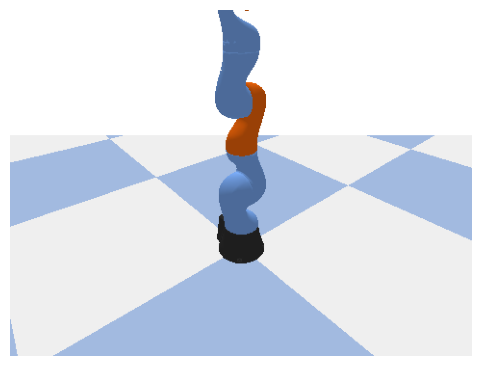

Number of joints: 7
{'index': 0, 'name': 'lbr_iiwa_joint_1', 'type': 0}
{'index': 1, 'name': 'lbr_iiwa_joint_2', 'type': 0}
{'index': 2, 'name': 'lbr_iiwa_joint_3', 'type': 0}
{'index': 3, 'name': 'lbr_iiwa_joint_4', 'type': 0}
{'index': 4, 'name': 'lbr_iiwa_joint_5', 'type': 0}
{'index': 5, 'name': 'lbr_iiwa_joint_6', 'type': 0}
{'index': 6, 'name': 'lbr_iiwa_joint_7', 'type': 0}


In [6]:
new_sim()
snapshot()

print(f"Number of joints: {get_num_joints()}")
for j in get_joint_info():
    print(j)


## Your Turn (Session 1 deliverable)
1. From the printed joint list above, count how many are revolute joints (type `0` = `JOINT_REVOLUTE`).
2. Call `get_end_effector_position()` right after `new_sim()` and note the starting (x, y, z).
3. In the text cell below, briefly explain the difference between the world frame and the tool frame in your own words.


In [7]:
# Your code here
print("End-effector start position:", get_end_effector_position())


End-effector start position: (-4.6749944025943655e-06, -2.3744188039354075e-12, 1.280999999977198)


_Write your explanation of world frame vs. tool frame here (double-click to edit this cell)._

---
## Instructor Note

This notebook is intentionally robot-agnostic in structure: the same session sequence (FK → IK →
pick-place → waypoints → sensing → sorting → capstone) transfers directly to the Dobot Magician or
any other small arm once hardware is available again. Consider a bonus session comparing simulated
vs. real-robot behavior at that point.
